In [6]:
import os
import sys
import plotly.graph_objects as go

import matplotlib.pyplot as plt

current_dir = os.getcwd()
project_root = current_dir[:current_dir.find("src") - 1]
sys.path.insert(0, project_root)
from src.models.filter_data.filter_data import *
from src.models.filter_data.feature_adder import *

In [7]:
l_min = 4
max_diff = 3
c_thresh = 0.9

csv_read_path = os.path.join(project_root, "data", "processed", "semi_processed.csv")

df = pd.read_csv(csv_read_path, encoding='utf-8')
df_c = df

In [8]:
csv_read_path = os.path.join(project_root, "data", "interim", "factors.csv")
df_factors = pd.read_csv(csv_read_path)
df_factors

coefs = {}
grouped = df_factors.groupby(['PowerPlantCode', 'PowerPlantName', "UnitCode"])

for (pp_code, pp_name, unit_code), g in grouped:
    uniques = g[["a1IndexGas", "b1IndexGas"]].drop_duplicates()
    coefs[(pp_name, unit_code)] = []
    for row in uniques.itertuples(index=False):
        coefs[(pp_name, unit_code)].append((row.a1IndexGas, row.b1IndexGas))

In [9]:
import plotly.express as px


def show(df_m1, save=False, param=None, ass=""):
    fig = px.scatter(df_m1, x="datetime", y='generation', color='is_good_peak',
                     title='Generation over Time by Batch Interval',
                     labels={'generation': 'Generation', 'datetime': 'Time'},
                     hover_data=['datetime', 'generation', 'temp_sens', 'interval_id'])

    if save:
        fig.write_html(
            f"{project_root}/src/visualization/unit_figs/filter5{ass}/{param['name']}-{param['code']}_l.html")
    else:
        fig.show()

    fig = px.scatter(df_m1, x="temp_sens", y='generation', color='is_good_peak',
                     title='Generation over Time by Batch Interval',
                     labels={'generation': 'Generation'},
                     hover_data=['datetime', 'generation', 'temp_sens'])
    
    n = param["name"]
    c = param["code"]
    for i in range(len(coefs[(n, c)])):
        a, b = coefs[(n, c)][i]
        x_line = np.linspace(df_m1["temp_sens"].min(), df_m1["temp_sens"].max(), 100)
        y_line = a * x_line + b
        
        fig.add_trace(go.Scatter(
            x=x_line,
            y=y_line,
            mode="lines",
            name=f"y = {a}x + {b}",
            line=dict(dash="dash", width=2)
        ))
    
    if save:
        fig.write_html(
            f"{project_root}/src/visualization/unit_figs/filter5{ass}/{param['name']}-{param['code']}_s.html")
    else:
        fig.show()
        
    

In [11]:
power_plants = df_c[['name', 'code']].drop_duplicates()

for row in power_plants.itertuples():
    name_plot, code_plot = row.name, row.code
    ds_n_c_plot = Data_selector(Data_selector(df_c).select_peaks(goodness=2))
    df_n_c_plot = ds_n_c_plot.filter_name_code(name_plot, code_plot)
    show(df_n_c_plot, save=True, param={"name": name_plot, "code": code_plot})

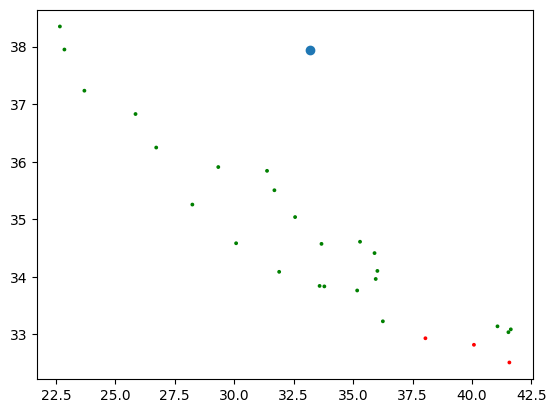

In [49]:
name_plot, code_plot = "سیکل ترکیبی یزد", "G12"
one_unit_df = Data_selector(Data_selector(df_c).filter_name_code(name_plot, code_plot)).select_peaks(goodness=4)

sens_temps = one_unit_df['temp_sens'].values
gens = one_unit_df['generation'].values

X, y = find_points_on_envelope(gens, sens_temps, bin_length=30)

near_envelope_indices = select_envelope_neighbors_indices(X, y, one_unit_df, alpha=2, beta=5)
all_indices.extend(near_envelope_indices)

is_in_area = (one_unit_df['is_good_peak'] == 5).values
X_all = sens_temps
#gens
colors = ['green' if val else 'red' for val in is_in_area]

plt.scatter(X_all, gens, s=3, color=colors)

#plt.plot(X_all,y_pred_all + 2)
#plt.plot(X_all,y_pred_all - 5)
#plt.plot(X_all,y_pred_all)
plt.scatter(X, y)


jonoob esfehan G12<= GX


In [18]:
is_in_area.any()

np.False_

In [7]:
csv_read_path = os.path.join(project_root, "data", "interim", "factors.csv")
df_factors = pd.read_csv(csv_read_path)

In [17]:
df_factors

,PowerPlantCode,PowerPlantName,UnitCode,Date,a1IndexGas,b1IndexGas
0,104,پرند,G16,2021-03-21,-1.0190,169.9
1,104,پرند,G11,2021-03-21,-0.8670,144.4
2,104,پرند,G15,2021-03-21,-1.0190,169.9
3,104,پرند,G13,2021-03-21,-0.8670,144.4
4,104,پرند,G14,2021-03-21,-1.0190,169.9
...,...,...,...,...,...,...
105187,917,حافظ,G11,2025-03-20,-0.7837,139.1
105188,917,حافظ,G13,2025-03-20,-0.7837,139.1
105189,917,حافظ,G14,2025-03-20,-0.7837,139.1
105190,917,حافظ,G15,2025-03-20,-0.7837,139.1


In [19]:
coefs = {}

In [20]:
grouped = df_factors.groupby(['PowerPlantCode', 'PowerPlantName', "UnitCode"])

for (pp_code, pp_name, unit_code), g in grouped:
    uniques = g[["a1IndexGas", "b1IndexGas"]].drop_duplicates()
    coefs[(pp_name, unit_code)] = []
    for row in uniques.itertuples(index=False):
        coefs[(pp_name, unit_code)].append((row.a1IndexGas, row.b1IndexGas))
    

In [21]:
coefs

{('پرند', 'G11'): [(-0.867, 144.4), (-0.9717, 162.0)],
 ('پرند', 'G12'): [(-0.867, 144.4), (-0.9717, 162.0)],
 ('پرند', 'G13'): [(-0.867, 144.4), (-1.0129, 168.8)],
 ('پرند', 'G14'): [(-1.019, 169.9), (-1.0129, 168.8)],
 ('پرند', 'G15'): [(-1.019, 169.9), (-1.0129, 168.8)],
 ('پرند', 'G16'): [(-1.019, 169.9), (-1.0129, 168.8)],
 ('شهدای پاکدشت - دماوند', 'G11'): [(-0.83, 144.34)],
 ('شهدای پاکدشت - دماوند', 'G12'): [(-0.83, 144.34)],
 ('شهدای پاکدشت - دماوند', 'G13'): [(-0.83, 144.34)],
 ('شهدای پاکدشت - دماوند', 'G14'): [(-0.83, 144.34)],
 ('شهدای پاکدشت - دماوند', 'G15'): [(-0.83, 144.34)],
 ('شهدای پاکدشت - دماوند', 'G16'): [(-0.83, 144.34)],
 ('شهدای پاکدشت - دماوند', 'G17'): [(-0.83, 144.34)],
 ('شهدای پاکدشت - دماوند', 'G18'): [(-0.83, 144.34)],
 ('شهدای پاکدشت - دماوند', 'G19'): [(-0.83, 144.34)],
 ('شهدای پاکدشت - دماوند', 'G20'): [(-0.83, 144.34)],
 ('شهدای پاکدشت - دماوند', 'G21'): [(-0.825, 149.3)],
 ('شهدای پاکدشت - دماوند', 'G22'): [(-0.825, 149.3)],
 ('قم', 'G11'): [(-0.7